# Exploratory Data Analysis — Olist E-commerce

This notebook explores the Olist e-commerce dataset to understand its structure and uncover patterns that will guide the machine learning and deep learning phases of the project.

In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

# Connect to the database
conn = sqlite3.connect("../data/ecommerce.db")

print("Connected. Ready to analyze.")

Connected. Ready to analyze.


## 1. Distribution of Review Scores

Most reviews are 5 stars, while low scores are rare. This is a strongly **imbalanced** distribution, which will need to be handled carefully when training the sentiment model in the deep learning phase.

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64


C:\Users\jorge\AppData\Local\Temp\ipykernel_17224\1342053355.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=reviews, x="review_score", palette="viridis")


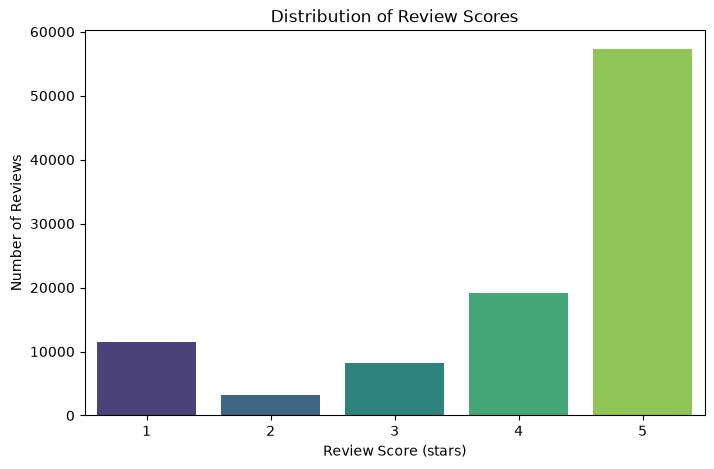

In [3]:
# Load review scores from the database
reviews = pd.read_sql("SELECT review_score FROM reviews;", conn)

# Count how many reviews per score
score_counts = reviews["review_score"].value_counts().sort_index()
print(score_counts)

# Plot it as a bar chart
plt.figure(figsize=(8, 5))
sns.countplot(data=reviews, x="review_score", palette="viridis")
plt.title("Distribution of Review Scores")
plt.xlabel("Review Score (stars)")
plt.ylabel("Number of Reviews")
plt.show()

## 2. Late vs On-Time Deliveries

Only **8.11%** of delivered orders arrive late. This is another imbalanced target: a naive model predicting "never late" would be 92% accurate yet useless. This motivates using proper evaluation metrics beyond accuracy in the machine learning phase.

is_late
False    88652
True      7826
Name: count, dtype: int64

Percentage late: 8.11 %


C:\Users\jorge\AppData\Local\Temp\ipykernel_17224\3589005738.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=delivered, x="is_late", palette="Set2")


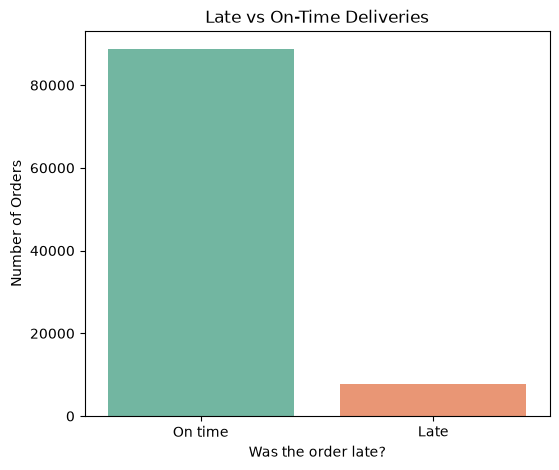

In [4]:
# Load the two delivery dates plus the order status
orders = pd.read_sql("""
    SELECT order_status,
           order_delivered_customer_date,
           order_estimated_delivery_date
    FROM orders;
""", conn)

# Keep only delivered orders (others have no real delivery date)
delivered = orders[orders["order_status"] == "delivered"].copy()

# Convert the text dates into real date values
delivered["delivered"] = pd.to_datetime(delivered["order_delivered_customer_date"])
delivered["estimated"] = pd.to_datetime(delivered["order_estimated_delivery_date"])

# An order is late if it arrived after the estimated date
delivered["is_late"] = delivered["delivered"] > delivered["estimated"]

# Count late vs on-time
late_counts = delivered["is_late"].value_counts()
print(late_counts)
print("\nPercentage late:", round(delivered["is_late"].mean() * 100, 2), "%")

# Plot it
plt.figure(figsize=(6, 5))
sns.countplot(data=delivered, x="is_late", palette="Set2")
plt.title("Late vs On-Time Deliveries")
plt.xlabel("Was the order late?")
plt.ylabel("Number of Orders")
plt.xticks([0, 1], ["On time", "Late"])
plt.show()

## 3. Orders Over Time

Order volume grows through 2017 and stabilizes in 2018. The sharp drop at the very end is not a real decline but the point where the dataset ends.

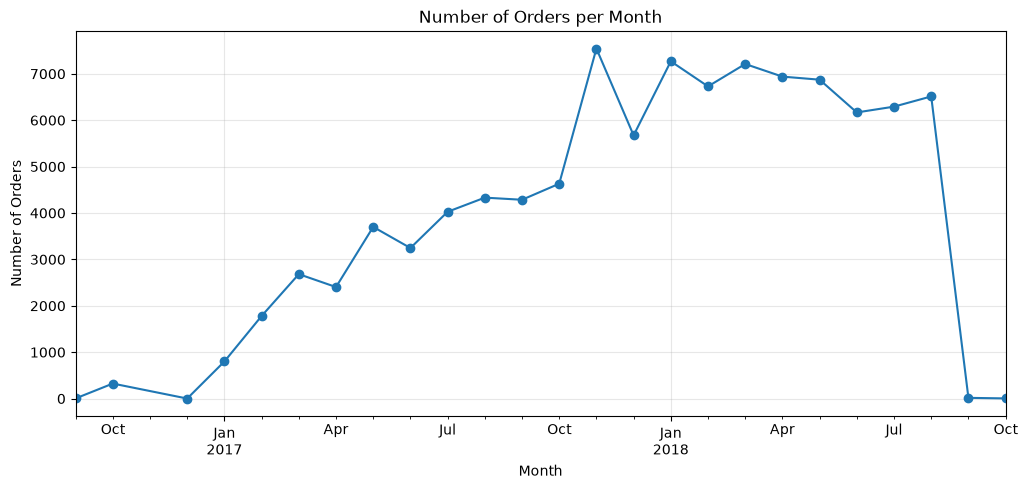

In [5]:
# Load purchase dates
sales = pd.read_sql("SELECT order_purchase_timestamp FROM orders;", conn)
sales["date"] = pd.to_datetime(sales["order_purchase_timestamp"])

# Group by month
sales["month"] = sales["date"].dt.to_period("M")
monthly = sales.groupby("month").size()

# Plot as a line
plt.figure(figsize=(12, 5))
monthly.plot(kind="line", marker="o")
plt.title("Number of Orders per Month")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.grid(True, alpha=0.3)
plt.show()

## 4. Does Lateness Affect Review Scores?

On-time orders average **4.29 stars**, while late orders drop to **2.57**. Delivery delays clearly hurt customer satisfaction. This links the two models of the project: predicting delays can help anticipate unhappy customers.

is_late
False    4.293737
True     2.566494
Name: review_score, dtype: float64


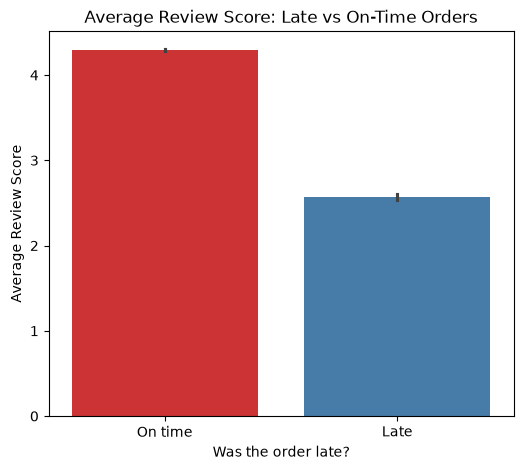

In [6]:
# Join orders and reviews to link lateness with review score
query = """
    SELECT o.order_status,
           o.order_delivered_customer_date,
           o.order_estimated_delivery_date,
           r.review_score
    FROM orders o
    JOIN reviews r ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered';
"""
df = pd.read_sql(query, conn)

# Build the is_late column again
df["delivered"] = pd.to_datetime(df["order_delivered_customer_date"])
df["estimated"] = pd.to_datetime(df["order_estimated_delivery_date"])
df["is_late"] = df["delivered"] > df["estimated"]

# Average review score by late/on-time
avg_score = df.groupby("is_late")["review_score"].mean()
print(avg_score)

# Plot
plt.figure(figsize=(6, 5))
sns.barplot(data=df, x="is_late", y="review_score", hue="is_late", palette="Set1", legend=False)
plt.title("Average Review Score: Late vs On-Time Orders")
plt.xlabel("Was the order late?")
plt.ylabel("Average Review Score")
plt.xticks([0, 1], ["On time", "Late"])
plt.show()

## 5. Top Product Categories

The best-selling categories are home, health & beauty, and sports & leisure, showing this is a general-purpose store with a strong presence in home and personal-care products.

category
bed_bath_table           11115
health_beauty             9670
sports_leisure            8641
furniture_decor           8334
computers_accessories     7827
housewares                6964
watches_gifts             5991
telephony                 4545
garden_tools              4347
auto                      4235
Name: count, dtype: int64


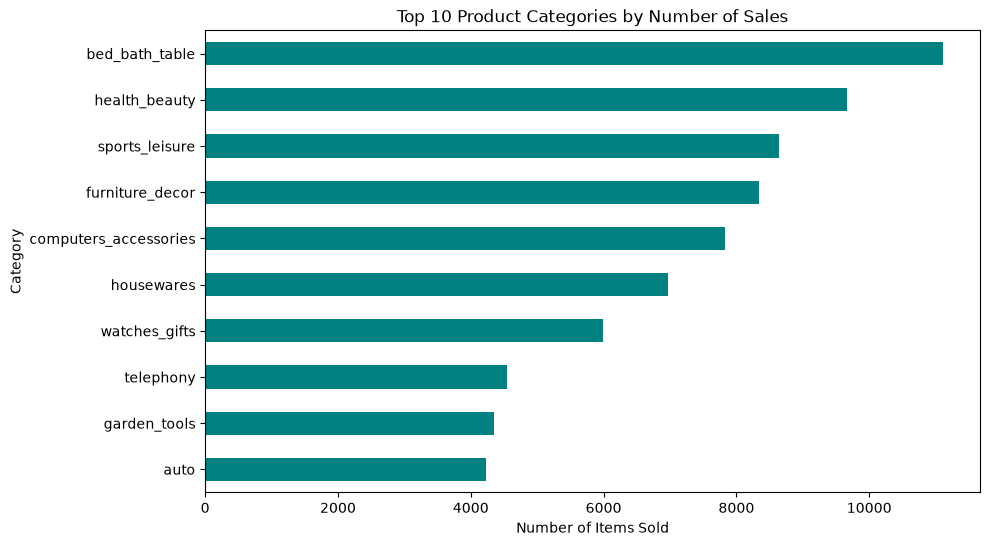

In [7]:
# Join order items with product categories (translated to English)
query = """
    SELECT ct.product_category_name_english AS category
    FROM order_items oi
    JOIN products p ON oi.product_id = p.product_id
    JOIN category_translation ct
        ON p.product_category_name = ct.product_category_name;
"""
cats = pd.read_sql(query, conn)

# Top 10 categories
top10 = cats["category"].value_counts().head(10)
print(top10)

# Plot horizontal bars
plt.figure(figsize=(10, 6))
top10.sort_values().plot(kind="barh", color="teal")
plt.title("Top 10 Product Categories by Number of Sales")
plt.xlabel("Number of Items Sold")
plt.ylabel("Category")
plt.show()